# Chapter 8 — LDA vs PBE: the GaAs lattice constant

Companion notebook to Chapter 8. We compare two exchange–correlation
functionals on the *same* GaAs structure by fitting each one's
energy-vs-volume curve (`code/08-functionals/eos_{lda,pbe}.dat`) to the
Birch–Murnaghan equation of state. The point: the functional, not the
convergence, sets the equilibrium lattice constant. Requirements: `numpy`,
`scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

BOHR = 0.52917721
d = Path('../code/08-functionals')

def bm(V, E0, V0, B0, B0p):
    eta = (V0/V)**(2/3)
    return E0 + 9*V0*B0/16*((eta-1)**3*B0p + (eta-1)**2*(6-4*eta))

def fit(fname):
    a, E = np.loadtxt(d/fname, skiprows=1, unpack=True)
    V = a**3/4
    p, _ = curve_fit(bm, V, E, p0=[E.min(), V[np.argmin(E)], 0.005, 4.0])
    a0 = (4*p[1])**(1/3) * BOHR
    return a, E, p, a0

a_l, E_l, p_l, a0_l = fit('eos_lda.dat')
a_p, E_p, p_p, a0_p = fit('eos_pbe.dat')
a_exp = 5.65325
for name, a0 in [('LDA', a0_l), ('PBE', a0_p)]:
    print(f'{name}: a0 = {a0:.4f} Ang  ({100*(a0-a_exp)/a_exp:+.2f}% vs exp {a_exp})')

LDA: a0 = 5.6123 Ang  (-0.72% vs exp 5.65325)
PBE: a0 = 5.7562 Ang  (+1.82% vs exp 5.65325)


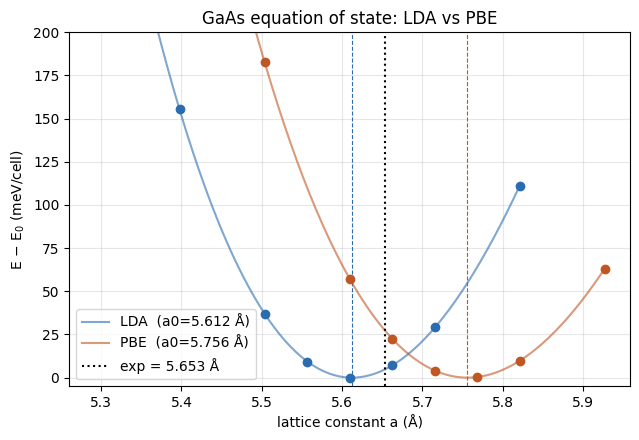

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (a, E, p, a0, c, lab) in [
        (a_l, E_l, p_l, a0_l, '#2b6cb0', 'LDA'),
        (a_p, E_p, p_p, a0_p, '#c05621', 'PBE')]:
    aa = a * BOHR
    dE = (E - p[0]) * 1000 * 13.6057          # relative energy, meV
    af = np.linspace(a.min(), a.max(), 200)
    dEf = (bm(af**3/4, *p) - p[0]) * 1000 * 13.6057
    ax.plot(aa, dE, 'o', color=c)
    ax.plot(af*BOHR, dEf, '-', color=c, alpha=0.6, label=f'{lab}  (a0={a0:.3f} Å)')
    ax.axvline(a0, color=c, ls='--', lw=0.8)
ax.axvline(5.65325, color='k', ls=':', label='exp = 5.653 Å')
ax.set_xlabel('lattice constant a (Å)')
ax.set_ylabel('E − E$_0$ (meV/cell)')
ax.set_ylim(-5, 200)
ax.set_title('GaAs equation of state: LDA vs PBE')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/08-lda-pbe-eos.png', dpi=120)
plt.show()

**What you see.** The two wells sit at visibly different lattice
constants: **LDA underbinds the volume** (a0 ≈ 5.61 Å, ~0.7 % *too small*),
**PBE overbinds** (a0 ≈ 5.76 Å, ~1.8 % *too large*), and the experimental
value sits between them. This LDA-under / GGA-over pattern is one of the
most reproducible facts in DFT — and it is purely a choice of functional,
computed here on identical cells, cutoffs, and k-grids. (PBEsol and many
meta-GGAs were designed precisely to land in the middle.)